### We will transform non-guassian distribution to Normal/Gaussian distribution

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

In [11]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv',usecols= ["Age","Fare","Survived"])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [12]:
print("Age Null values: ",df["Age"].isnull().sum())
print("Fare Null values: ",df["Fare"].isnull().sum()) 

Age Null values:  177
Fare Null values:  0


In [13]:
from sklearn.impute import SimpleImputer 

impute = SimpleImputer(strategy="median")

df["Age"] = impute.fit_transform(df[["Age"]])

print("Age Null values: ",df["Age"].isnull().sum())

Age Null values:  0


## Using FunctionTransformer

In [14]:
print("Before Transformation skew: ",df["Fare"].skew())   # clearly Right-skewed

Before Transformation skew:  4.787316519674893


Text(0.5, 1.0, 'Fare QQ-Plot')

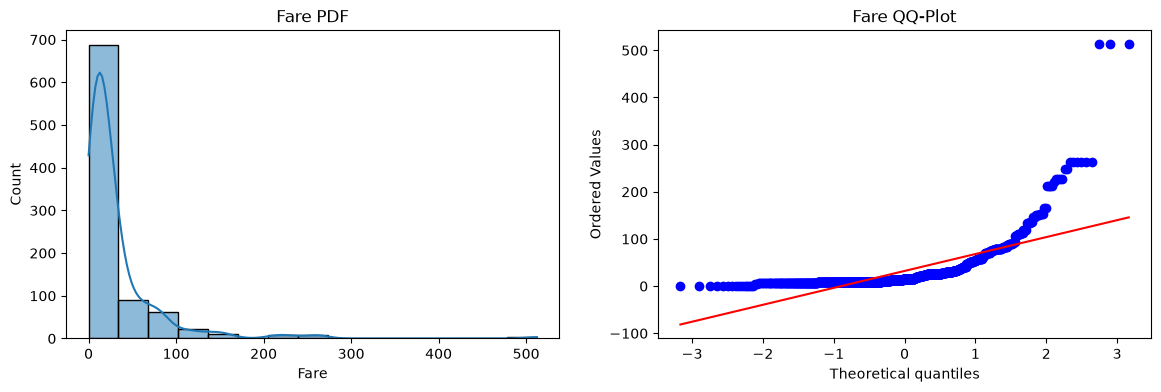

In [15]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
sns.histplot(df["Fare"], kde=True, bins=15)
plt.title("Fare PDF")

plt.subplot(1,2,2)
stats.probplot(df["Fare"], dist="norm", plot=plt)
plt.title("Fare QQ-Plot")

In [16]:
from sklearn.preprocessing import FunctionTransformer

trf = FunctionTransformer(func=np.log1p)

df["fare_transformed"] = trf.fit_transform(df[["Fare"]]).values.flatten()

print("After Transformation skew: ",df["fare_transformed"].skew())

After Transformation skew:  0.3949280095189306


Text(0.5, 1.0, 'After log Transformation on Fare column')

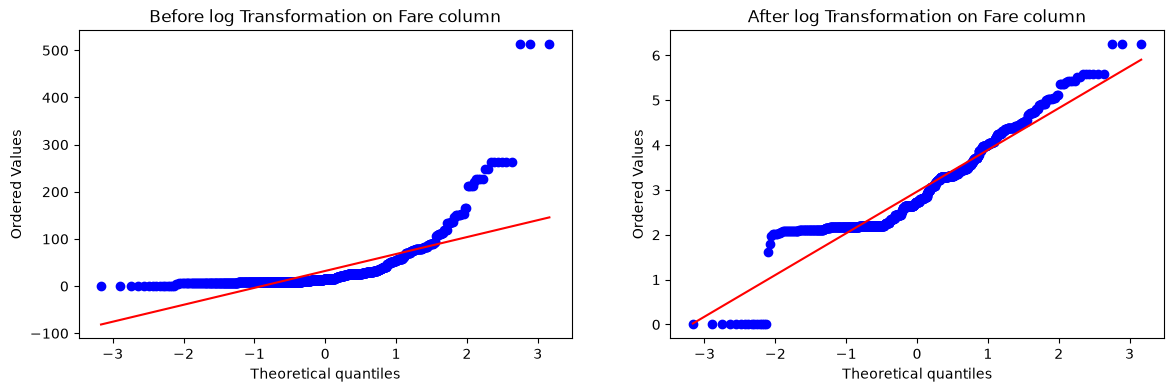

In [17]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(df["Fare"], dist="norm",plot=plt)
plt.title("Before log Transformation on Fare column")

plt.subplot(1,2,2)
stats.probplot(df["fare_transformed"], dist="norm",plot=plt)
plt.title("After log Transformation on Fare column")

### In this procedure we have to manually find the optimal Tranformer 

## The Solution: Box-Cox & Yeo-Johnson

- These methods AUTOMATICALLY find the OPTIMAL transformation

## Applying box-Cox 
- Data must be greater than zero

In [18]:
from scipy.stats import boxcox, yeojohnson

In [19]:
print("Before Transformation: ",df["Age"].skew())

Before Transformation:  0.5102446555756495


In [20]:
df["Age_boxcox"], lambda_boxcox = boxcox(df["Age"])

print("After Box-Cox Transformation: ",df["Age_boxcox"].skew())
print("Best lambda value using boxcox: ",lambda_boxcox)

After Box-Cox Transformation:  0.060507638965793795
Best lambda value using boxcox:  0.796453194094064


Text(0.5, 1.0, 'After boxcox Transformation on Age column')

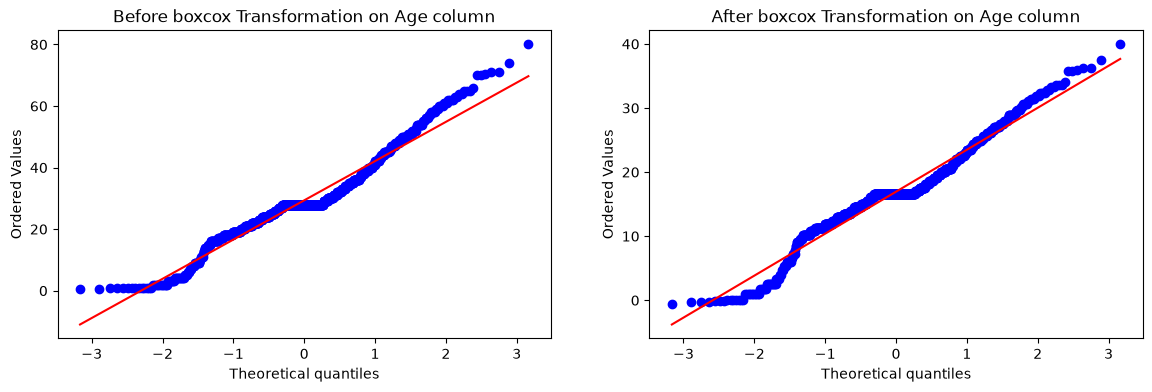

In [21]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(df["Age"], dist="norm", plot=plt)
plt.title("Before boxcox Transformation on Age column")

plt.subplot(1,2,2)
stats.probplot(df["Age_boxcox"], dist="norm", plot=plt)
plt.title("After boxcox Transformation on Age column")

## Applying yeo-johnson

- Best of all

In [22]:
print("Before yeo-johnson Transformation: ",df["Fare"].skew())

Before yeo-johnson Transformation:  4.787316519674893


In [23]:
df["fare_yeo"], lambda_yeo = yeojohnson(df["Fare"])

print("After yeo-johnson Transformation: ", df["fare_yeo"].skew())

print("Best lambda value using yeo-johnson: ",lambda_yeo)

After yeo-johnson Transformation:  -0.040329191007035935
Best lambda value using yeo-johnson:  -0.09778702988280082


Text(0.5, 1.0, 'After yeo-johnson Transformation on Fare column')

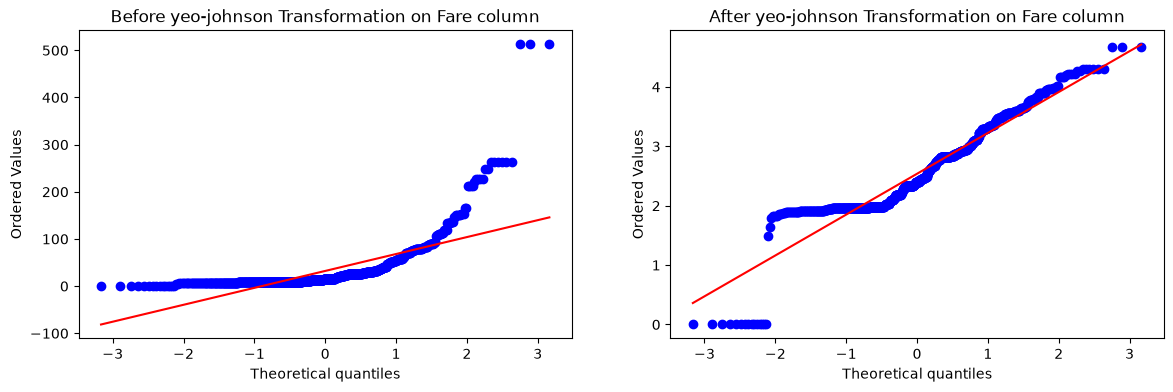

In [24]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(df["Fare"], dist="norm", plot=plt)
plt.title("Before yeo-johnson Transformation on Fare column")

plt.subplot(1,2,2)
stats.probplot(df["fare_yeo"], dist="norm", plot=plt)
plt.title("After yeo-johnson Transformation on Fare column" )

## Applying PowerTransformer on full dataset

In [25]:
con = pd.read_csv("concrete_data.csv")
con.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [38]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()   # default is yeo-johnson we can also write method="boxcox" but we want yeojohnson to perform

In [39]:
con_transformed = pt.fit_transform(con)

pd.DataFrame({"cols":con.columns, "yeo-johnson_lambdas":pt.lambdas_})

,cols,yeo-johnson_lambdas
0,Cement,0.169544
1,Blast Furnace Slag,0.016633
2,Fly Ash,-0.136480
3,Water,0.808438
4,Superplasticizer,0.264160
5,Coarse Aggregate,1.129395
6,Fine Aggregate,1.830764
7,Age,0.001771
8,Strength,0.565507


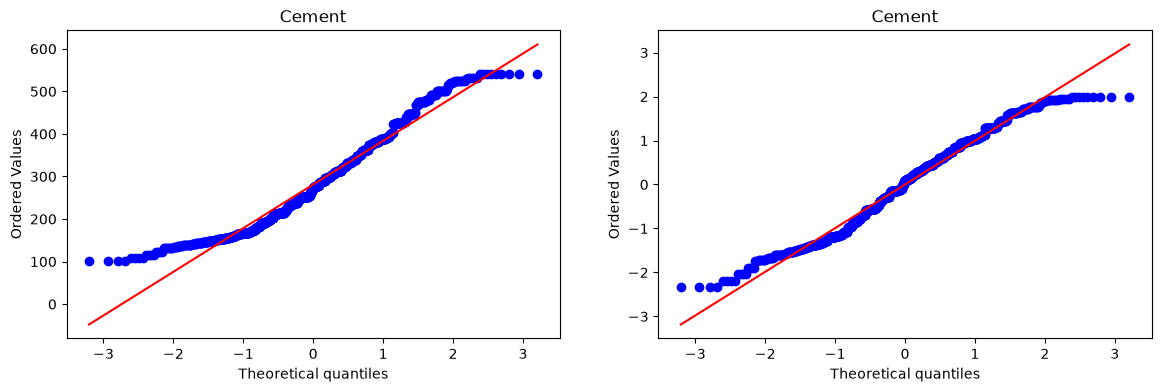

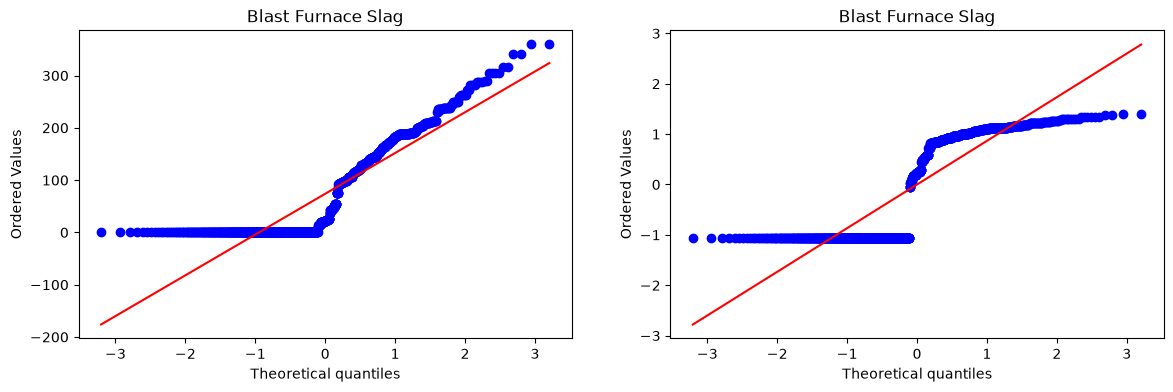

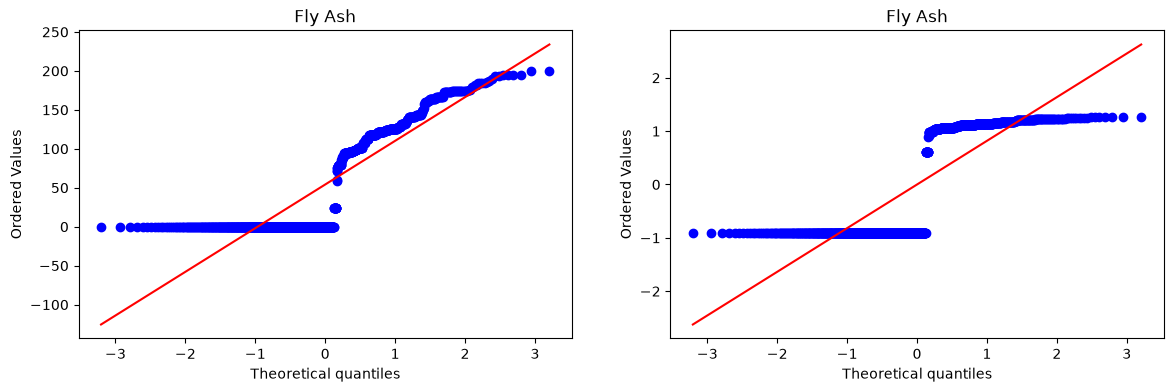

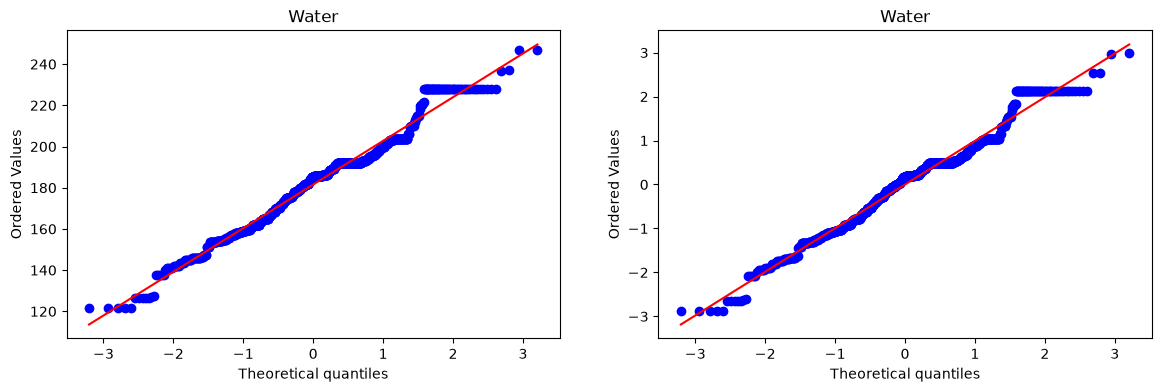

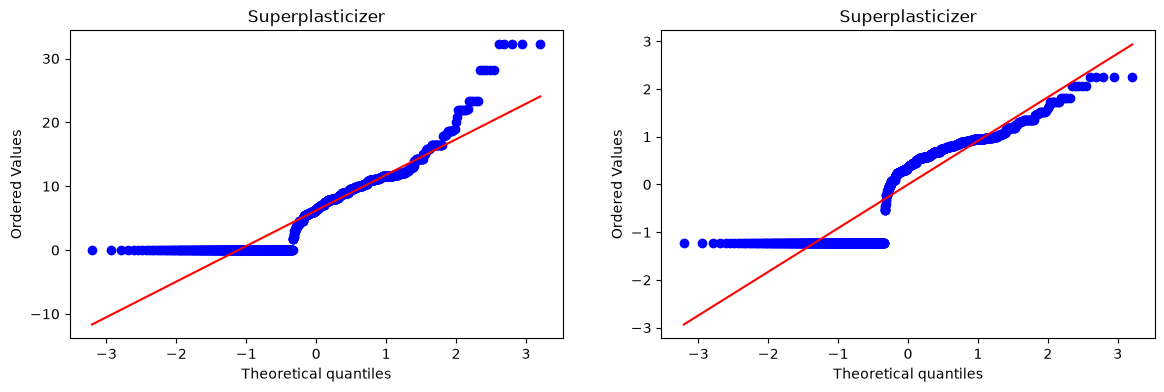

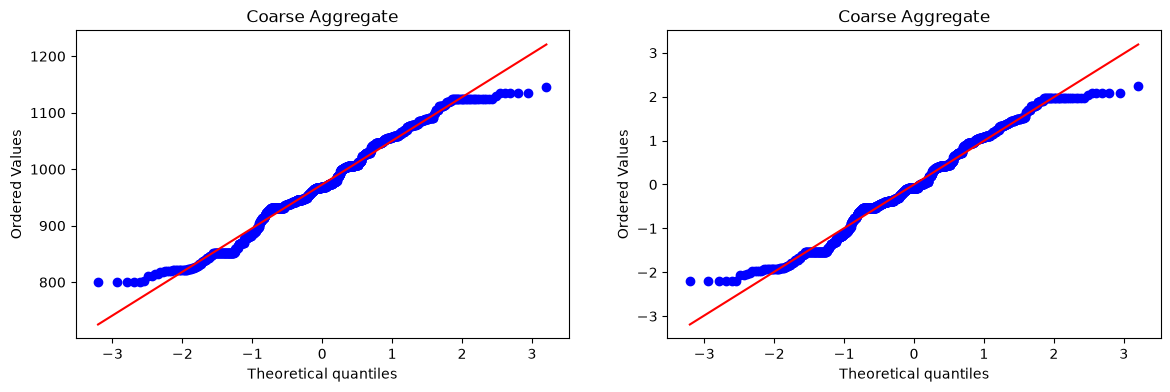

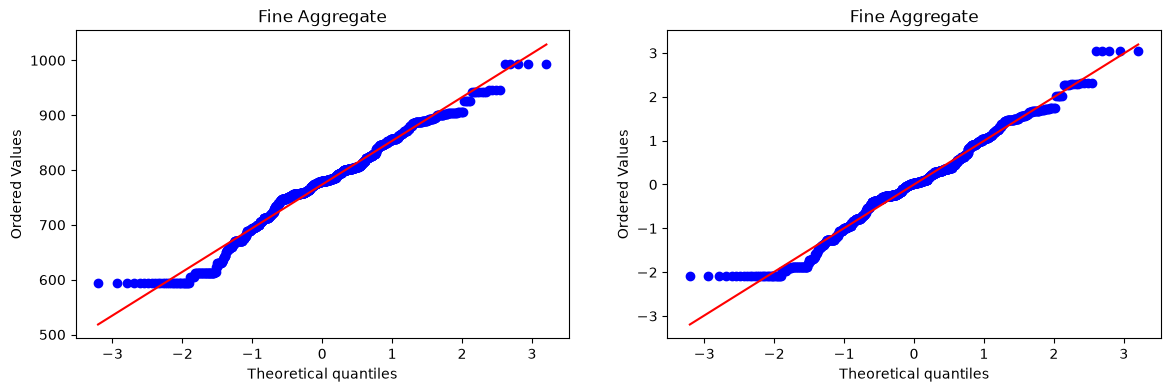

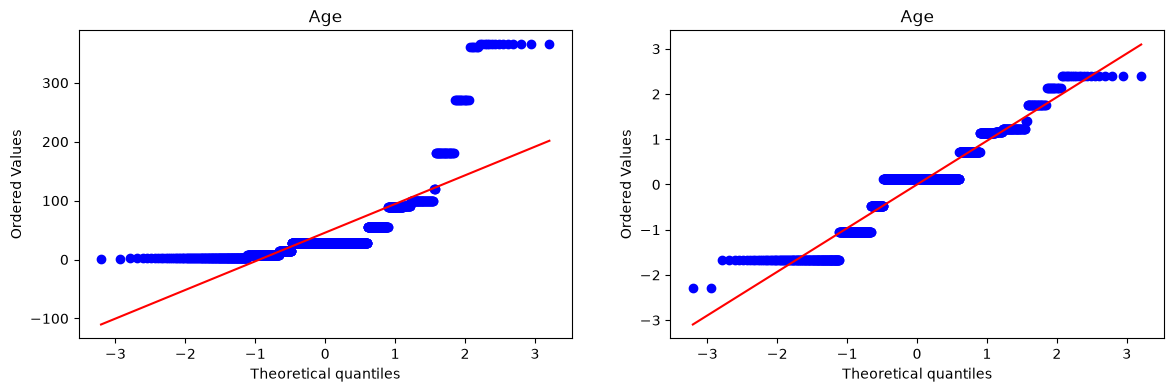

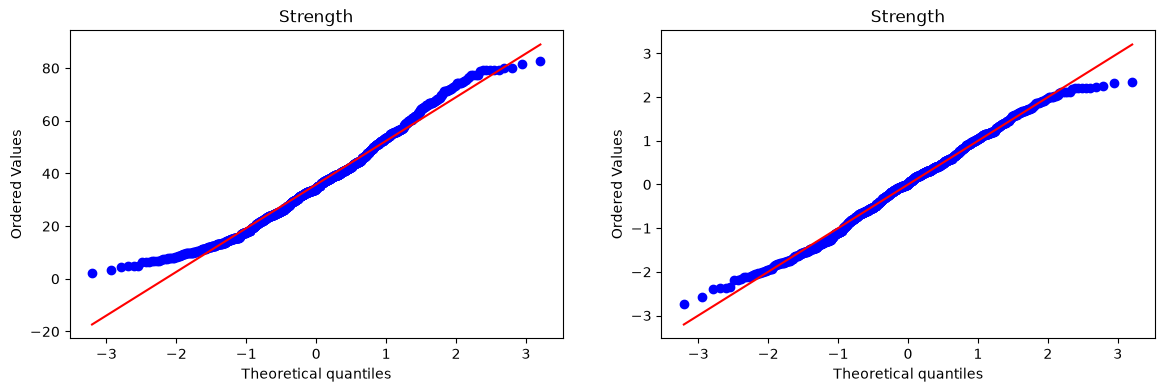

In [40]:
con_transformed = pd.DataFrame(con_transformed, columns = con.columns)

for col in con_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(con[col], dist="norm",plot=plt)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(con_transformed[col], dist="norm",plot=plt)
    plt.title(col)

## Summary

In this notebook, I explored different transformation techniques to make skewed data more closely follow a normal distribution. The transformations applied and compared were:

* **FunctionTransformer:** Applied custom transformations such as the logarithmic transformation to reduce skewness.
* **Box-Cox Transformation:** Used for strictly positive data to improve normality.
* **Yeo-Johnson Transformation:** Applied to data containing zero or negative values, making it a more flexible alternative to Box-Cox.

The effectiveness of each transformation was evaluated by comparing **Q-Q plots before and after transformation**. This helped visualize how closely the transformed data aligned with a normal distribution.

### Key Takeaways

* Different transformations are suitable for different types of data.
* **Log transformation** reduces right skewness but may not always achieve normality.
* **Box-Cox** is effective for strictly positive data.
* **Yeo-Johnson** is more flexible as it supports positive, zero, and negative values.
* **Q-Q plots** provide a simple and effective way to visually assess whether a transformation has made the data more closely follow a normal distribution.
* The choice of transformation depends on the characteristics of the data and should be validated through visual inspection.
